In [1]:
import random
import math
from crossover import *
from fitness import *
from initializers import *
from mutation import *
from operations import *
from population import *
from program import *
from selection import *

## 3.1 The Effect of Operators

Measuring the quality gain and success rate requires creating a custom `stats_gatherer` function that is passed to the `Population`.

In [2]:
def q_omega_stats(population):
    quality_gain_total = 0.0
    success_count = 0
    for member in population.members:
        member_fitness = population._internal_fitness(member)
        # Notice that the value is subtracted rather than added.
        # This is to keep the convention that positive quality gain is good
        # even though lower fitness is better.
        quality_gain_total -= member_fitness - member.parent_fitness
        if member_fitness < member.parent_fitness:
            success_count += 1
    population_size = len(population.members)
    return {"quality_gain": quality_gain_total / population_size, "success_rate": success_count / population_size}

In [3]:
import random
import numpy as np
import matplotlib.pyplot as plt

random.seed(203340)

In [4]:
def plot_evolution(population, generation_count, stop_at_fitness):
    (generations, means, mins, all_time_best_fitness, all_time_best_program, all_custom_stats) = population.evolve(generation_count, stop_at_fitness)
    fig, ax = plt.subplots()
    ax.set_title(F"Best Fitness")
    ax.set_xlabel("Generation")
    ax.set_ylabel("Fitness")
    ax.plot(generations, mins)
    plt.show()
    all_time_best_program.print_readable_code()
    return (generations, means, mins, all_time_best_fitness, all_time_best_program, all_custom_stats)

def plot_1d_solution(x_test, y_test, program):
    y_hats = [program.execute(x)[0] for x in x_test]
    fig, ax = plt.subplots()
    ax.plot(x_test, y_test, label="Actual")
    ax.plot(x_test, y_hats, label="Predicted")
    ax.legend()
    plt.show()

def plot_q_omega(generations, quality_gains, success_rates):
    plt.plot(generations, quality_gains)
    plt.plot([generations[0], generations[-1]], [0,0], linestyle="dashed", color="black")
    plt.xlabel("Generation")
    plt.ylabel("Quality Gain")
    plt.title("Quality Gain over Time")
    plt.figure()
    plt.plot(generations, success_rates)
    plt.xlabel("Generation")
    plt.ylabel("Success Rate")
    plt.title("Success Rate over Time")
    plt.show()

def run(operations, mutation_func, program_mutation_rate, crossover_rate):
    x_train = np.linspace(0, 2 * np.pi, 100)
    y_train = np.sin(x_train)
    x_train = x_train.tolist()
    y_train = y_train.tolist()
    fitness_func = mse_fitness(x_train, y_train)
    selection_func = binary_tournament_selection
    instruction_count = 10
    register_count = 10
    output_value_count = 1
    register_initializer = RI_always_one
    crossover_func=standard_crossover_2pt()
    survival_selection_func = None
    stats_gatherer = q_omega_stats
    mu_plus_lambda = False
    lam = 1000
    nu = 500
    mu = 1000

    pop = Population(lam, nu, mu, selection_func, mutation_func, program_mutation_rate, crossover_rate, \
                    instruction_count, register_count, output_value_count, operations, register_initializer, \
                    fitness_func, crossover_func, survival_selection_func, stats_gatherer, mu_plus_lambda)
    
    (generations, means, mins, all_time_best_fitness, all_time_best_program, all_custom_stats) = plot_evolution(pop, 100, 0.00001)
    plot_1d_solution(x_train, y_train, all_time_best_program)
    quality_gains = [stats["quality_gain"] for stats in all_custom_stats]
    success_rates = [stats["success_rate"] for stats in all_custom_stats]
    plot_q_omega(generations, quality_gains, success_rates)

The following shows the quality gain and success rate when using only the mutation operator.

Beginning evolution.
Completed 3/100 generations. Best Fitness: 0.28450588260192533					

c:\Users\Patri\source\repos\LGP\fitness.py:15: RuntimeWarning: overflow encountered in square
  error += (y - y_hat) ** 2


Completed 100/100 generations. Best Fitness: 0.2690664036536126					
Evolution complete.


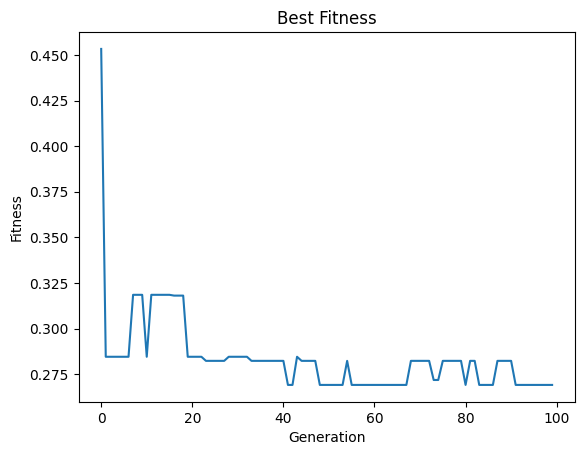

# Register Initialization
r0 = 1.0
r1 = 1.0
r2 = 1.0
r3 = 1.0
r4 = 1.0
r5 = 1.0
r6 = 1.0
r7 = 1.0
r8 = 1.0
r9 = 1.0
read_input_into_registers()
# Start of Program
r3 = r2 + r4
r5 = r3 / r7
r5 = r1 + r6
r5 = sqrt(|r5|)
r6 = r6 * r2
r6 = r5 - r0
r3 = (|r7|+epsilon) ** r1
r0 = (|r0|+epsilon) ** r6
r6 = r2 ** 2
r9 = ln(|r5|)
# End of Program


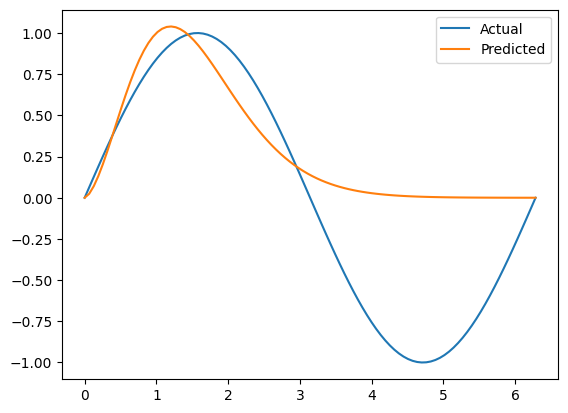

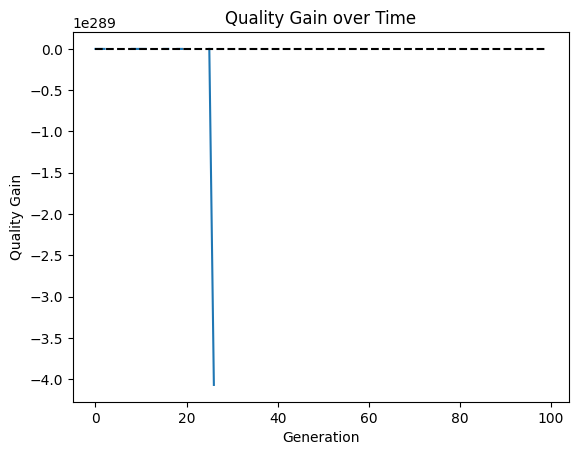

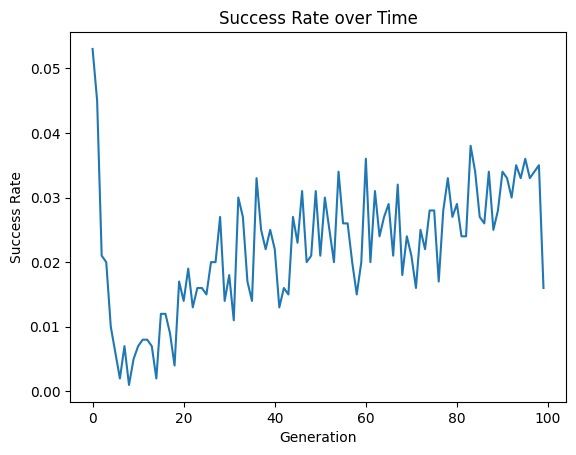

In [5]:
operations = [Addition, Subtraction, Multiplication, Division, Square, SquareRoot, Exponent, Logarithm]
mutation_func = standard_mutation(operations, 0.25, 0.00)
program_mutation_rate = 1.0
crossover_rate = 0.0

run(operations, mutation_func, program_mutation_rate, crossover_rate)

The quality gain tends to be zero, indicating a net zero effect, or very close to zero. The success rate is also very low across all generations, however it trends upwards.

The following does the same with only the crossover operator.

Beginning evolution.
Completed 100/100 generations. Best Fitness: 0.43250688111018804					
Evolution complete.


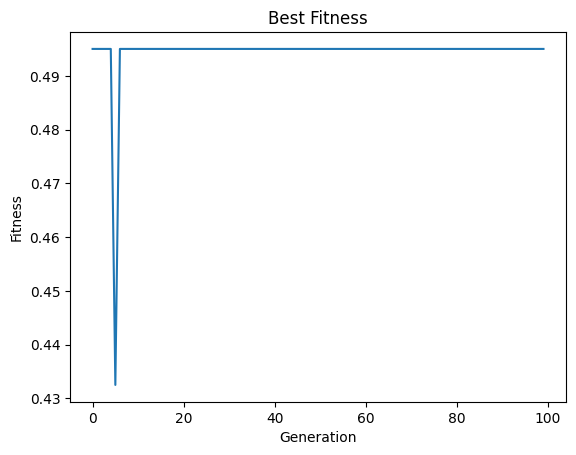

# Register Initialization
r0 = 1
r1 = 1
r2 = 1
r3 = 1
r4 = 1
r5 = 1
r6 = 1
r7 = 1
r8 = 1
r9 = 1
read_input_into_registers()
# Start of Program
r7 = r0 - r9
r9 = (|r7|+epsilon) ** r6
r3 = r9 / r5
r8 = r8 - r0
r4 = (|r2|+epsilon) ** r3
r1 = (|r7|+epsilon) ** r8
r8 = r2 + r1
r0 = r1 - r4
r6 = r0 / r8
r5 = (|r1|+epsilon) ** r5
# End of Program


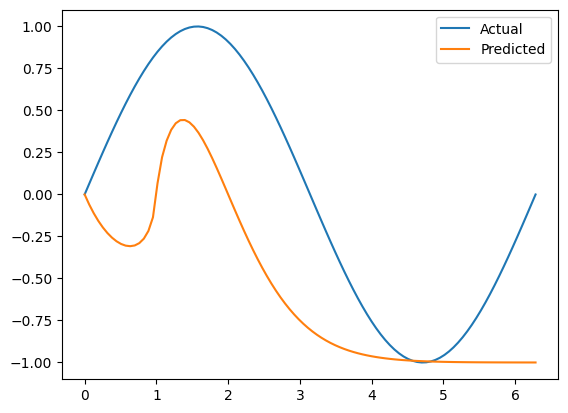

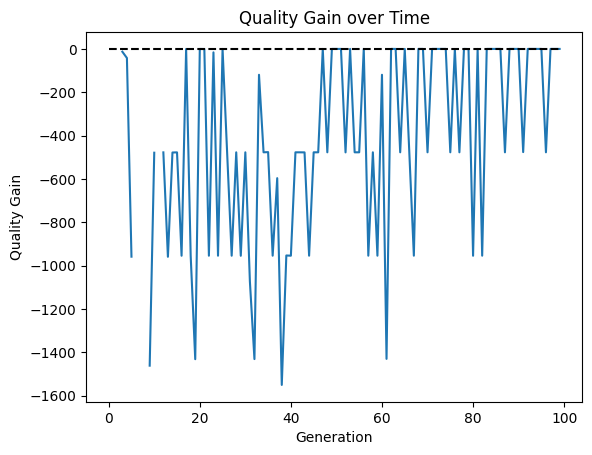

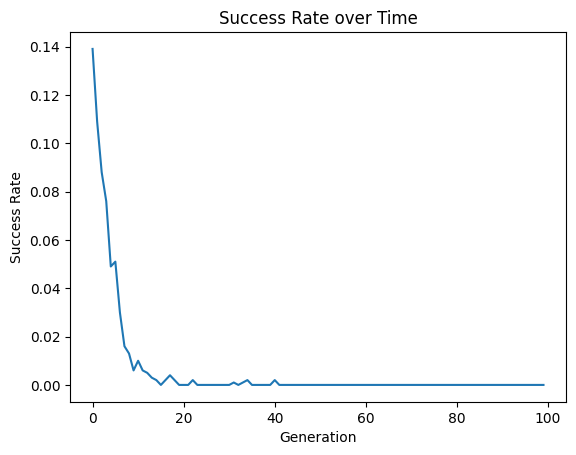

In [6]:
operations = [Addition, Subtraction, Multiplication, Division, Square, SquareRoot, Exponent, Logarithm]
mutation_func = standard_mutation(operations, 0.25, 0.00)
program_mutation_rate = 0.0
crossover_rate = 1.0

run(operations, mutation_func, program_mutation_rate, crossover_rate)

The quality gain fluctuates between less and more negative values, with some being very large. The conclusion is that crossover is a very destructive operator, especially in light of the success rate, which declines over the generations.

Finally, the following does the same with mutation only, but the mutation function randomly generates entirely new programs.

Beginning evolution.
Completed 100/100 generations. Best Fitness: 0.28450588260192533					
Evolution complete.


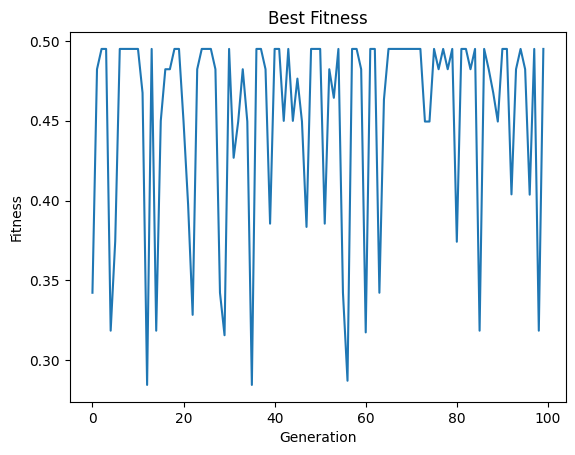

# Register Initialization
r0 = 1
r1 = 1
r2 = 1
r3 = 1
r4 = 1
r5 = 1
r6 = 1
r7 = 1
r8 = 1
r9 = 1
read_input_into_registers()
# Start of Program
r7 = r4 + r8
r6 = sqrt(|r5|)
r7 = sqrt(|r6|)
r3 = r8 + r2
r3 = (|r1|+epsilon) ** r0
r4 = r0 * r7
r9 = r1 - r9
r2 = r3 - r0
r9 = r5 / r5
r0 = (|r0|+epsilon) ** r2
# End of Program


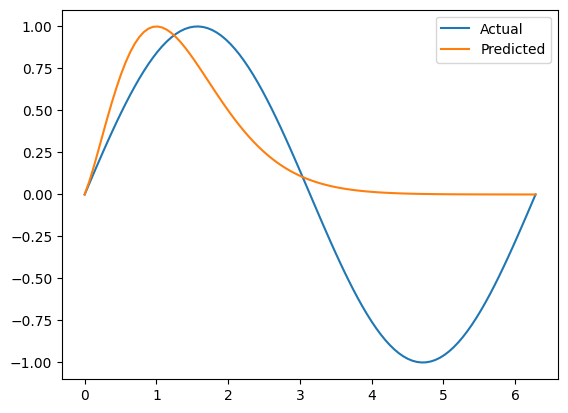

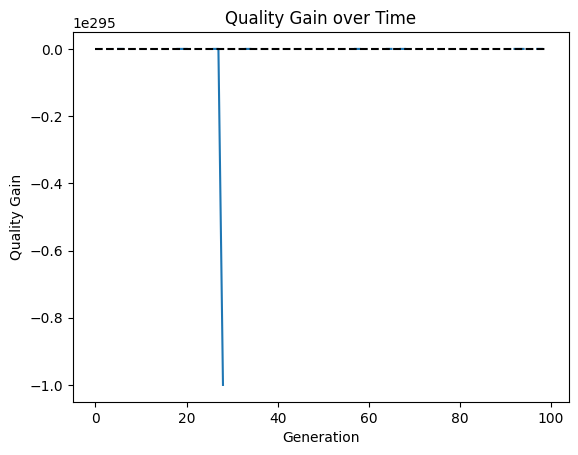

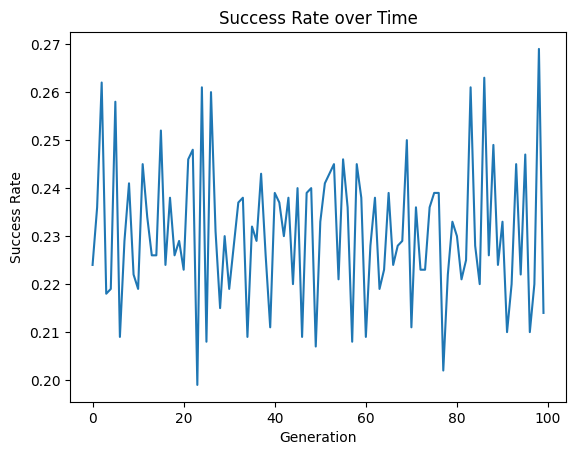

In [7]:
operations = [Addition, Subtraction, Multiplication, Division, Square, SquareRoot, Exponent, Logarithm]
mutation_func = random_generation_mutation(operations, RI_always_one)
program_mutation_rate = 1.0
crossover_rate = 0.0

run(operations, mutation_func, program_mutation_rate, crossover_rate)

The quality gain for random generation is the same as for mutation, which might indicate the efficacy of random search on this problem, especially given that the solution it produced was similar to that of mutation. Unsurprisingly, the success rate shows no trend over time, as offspring have no dependence on their parents.

Overall, success rate is a more useful measure than quality gain, because it cuts through the issue of miniscule changes in fitness. The proportions are much more significant. Looking at either metric gives a pessimistic view of the evolutionary process, as the operators alone are very destructive, and selection does the heavy lifting to fix that.

## Introns

In [8]:
def intron_stats(population):
    semantic_intron_ratio = sum([program.semantic_intron_ratio() for program in population.members]) / len(population.members)
    structural_inton_ratio = sum([program.structural_intron_ratio() for program in population.members]) / len(population.members)
    return {"semantic_intron_ratio": semantic_intron_ratio, "structural_intron_ratio": structural_inton_ratio}

def plot_intron_stats(generations, semantic_intron_ratios, structural_intron_ratios):
    plt.plot(generations, semantic_intron_ratios, label="Semantic Introns")
    plt.plot(generations, structural_intron_ratios, label="Structural Introns")
    plt.xlabel("Generation")
    plt.ylabel("Proportion of Semantic Introns")
    plt.title("Introns")
    plt.legend()
    plt.show()

In [9]:
def plot_evolution2(population, generation_count, stop_at_fitness):
    (generations, means, mins, all_time_best_fitness, all_time_best_program, all_custom_stats) = population.evolve(generation_count, stop_at_fitness)
    fig, ax = plt.subplots()
    ax.set_title(F"Best Fitness")
    ax.set_xlabel("Generation")
    ax.set_ylabel("Fitness")
    ax.plot(generations, mins)
    plt.show()
    all_time_best_program.print_readable_code()
    return (generations, means, mins, all_time_best_fitness, all_time_best_program, all_custom_stats)

def run2(operations, mutation_func, program_mutation_rate, crossover_rate):
    x_train = np.linspace(0, 2 * np.pi, 100)
    y_train = np.sin(x_train)
    x_train = x_train.tolist()
    y_train = y_train.tolist()
    fitness_func = mse_fitness_semantic_vector(x_train, y_train)
    selection_func = binary_tournament_selection
    instruction_count = 10
    register_count = 10
    output_value_count = 1
    register_initializer = RI_always_one
    crossover_func=standard_crossover_2pt()
    survival_selection_func = binary_tournament_selection
    stats_gatherer = intron_stats
    mu_plus_lambda = True
    lam = 100
    nu = 50
    mu = 100

    pop = Population(lam, nu, mu, selection_func, mutation_func, program_mutation_rate, crossover_rate, \
                    instruction_count, register_count, output_value_count, operations, register_initializer, \
                    fitness_func, crossover_func, survival_selection_func, stats_gatherer, mu_plus_lambda, always_run_fitness_func=True)
    
    (generations, means, mins, all_time_best_fitness, all_time_best_program, all_custom_stats) = plot_evolution(pop, 50, 0.00001)
    plot_1d_solution(x_train, y_train, all_time_best_program)
    semantic_intron_ratios = [stats["semantic_intron_ratio"] for stats in all_custom_stats]
    structural_intron_ratios = [stats["structural_intron_ratio"] for stats in all_custom_stats]
    plot_intron_stats(generations, semantic_intron_ratios, structural_intron_ratios)

Beginning evolution.
Completed 21/50 generations. Best Fitness: 0.49499999999999994					

c:\Users\Patri\source\repos\LGP\fitness.py:34: RuntimeWarning: overflow encountered in square
  error += (y - y_hat) ** 2


Completed 50/50 generations. Best Fitness: 0.49499999999999994					
Evolution complete.


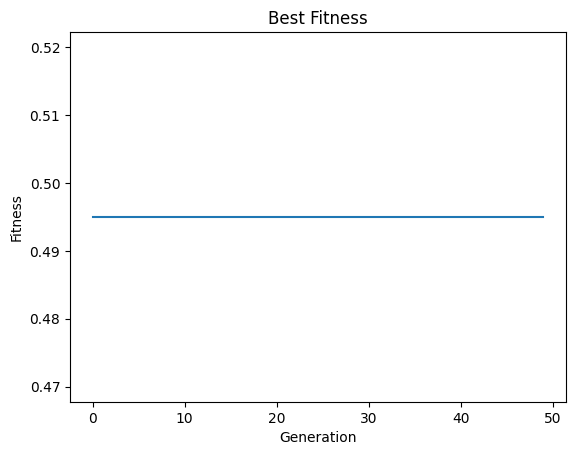

# Register Initialization
r0 = 1
r1 = 1
r2 = 1
r3 = 1
r4 = 1
r5 = 1
r6 = 1
r7 = 1
r8 = 1
r9 = 1
read_input_into_registers()
# Start of Program
r0 = ln(|r0|)
r5 = ln(|r4|)
r4 = r2 / r9
r7 = r5 - r6
r0 = ln(|r8|)
r5 = sqrt(|r6|)
r6 = sqrt(|r1|)
r2 = r1 + r6
r4 = r0 ** 2
r6 = r3 ** 2
# End of Program


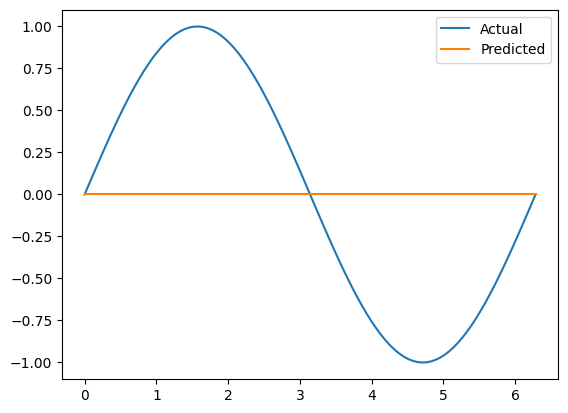

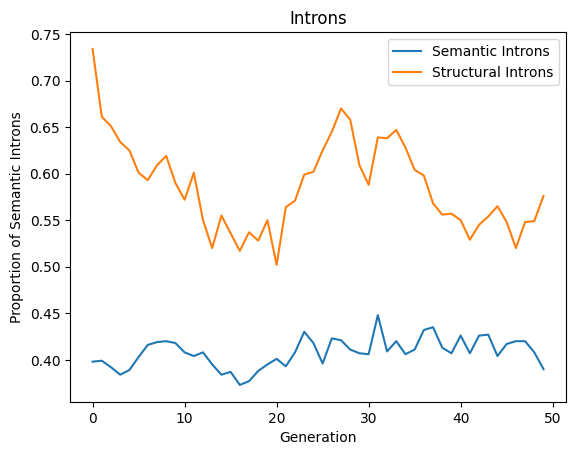

In [10]:
operations = [Addition, Subtraction, Multiplication, Division, Square, SquareRoot, Exponent, Logarithm]
mutation_func = standard_mutation(operations, 0.25, 0.00)
program_mutation_rate = 1.0
crossover_rate = 0.9

run2(operations, mutation_func, program_mutation_rate, crossover_rate)

The structural introns outnumber the semantic introns. It is easy for the output to not depend on an instruction. On the other hand, it is hard for an instruction to not modify any register (which is required of semantic introns), even if those changes do not contribute to the output. The reason that roughly 40% of instructions are semantic introns is that the initial register values are all one. Multiplication, division, and exponentiation by one all result in unchanged values.